In [43]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Importação dos Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df = pd.read_csv('Dataset/earthquakes_cleaned.csv')

In [44]:
df_model = df.copy()
df_model['alert'] = df_model['alert'].replace('Unknown', 'No_Alert')

# 2. Separar Features (X) e Target (y)
colunas_para_remover = ['alert', 'date']
X = df_model.drop(columns=colunas_para_remover)
y = df_model['alert']

# ---------------------------------------------------------
# 3. Codificação manual do Target
# ---------------------------------------------------------
# Criamos um dicionário com a ordem lógica de gravidade (do menor para o maior)
mapeamento_alertas = {
    'No_Alert': 0,
    'green': 1,
    'yellow': 2,
    'orange': 3,
    'red': 4
}

# Aplicamos o mapeamento à coluna alvo
y_encoded = y.map(mapeamento_alertas)

print(f"Mapeamento lógico das classes aplicado: {mapeamento_alertas}")

# Criamos também o dicionário inverso (para podermos traduzir de volta no futuro)
mapeamento_inverso = {valor: classe for classe, valor in mapeamento_alertas.items()}
# ---------------------------------------------------------

# # 3. Codificar a variável alvo (Target) para números
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)
#
# # Visualizar o mapeamento das classes
# classes_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print(f"Mapeamento das classes alvo: {classes_mapping}")

# 4. Separar colunas numéricas e categóricas
num_features = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 5. Criar o pré-processador para os modelos clássicos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

# 6. Divisão em Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Amostras de Treino: {X_train.shape[0]} | Amostras de Teste: {X_test.shape[0]}")

Mapeamento lógico das classes aplicado: {'No_Alert': 0, 'green': 1, 'yellow': 2, 'orange': 3, 'red': 4}
Amostras de Treino: 481 | Amostras de Teste: 121


C:\Users\julio\AppData\Local\Temp\ipykernel_39776\3130347908.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [45]:
# Configurar os modelos que precisam de pré-processamento
# Usamos class_weight='balanced' onde possível para compensar o domínio da classe 'No_Alert'
# Modelos do Scikit-Learn continuam na CPU.
# XGBoost e LightGBM configurados para buscar a GPU.
pipeline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    # Ativando GPU no XGBoost
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, device='cuda'),
    # Ativando GPU no LightGBM
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1, device='gpu'),
    "SVC (Support Vector)": SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}
trained_models = {}

print("Iniciando treinamento dos modelos em Pipeline...\n")

for name, model in pipeline_models.items():
    print(f"--- Treinando {name} ---")

    # Criar e treinar o pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)

    # Prever e avaliar
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Salvar resultados e pipeline
    results[name] = {'Accuracy': acc, 'F1-Score (Weighted)': f1, ""}
    trained_models[name] = clf
    print(f"F1-Score: {f1:.4f}\n")

Iniciando treinamento dos modelos em Pipeline...

--- Treinando Logistic Regression ---
F1-Score: 0.9465

--- Treinando Random Forest ---
F1-Score: 0.9478

--- Treinando XGBoost ---


C:\Users\julio\PycharmProjects\Earthquake_Model\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:16:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-Score: 0.9829

--- Treinando LightGBM ---
F1-Score: 0.9599

--- Treinando SVC (Support Vector) ---
F1-Score: 0.9652

--- Treinando KNN ---
F1-Score: 0.9391



C:\Users\julio\PycharmProjects\Earthquake_Model\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [46]:
# O CatBoost usa os dados originais (sem OneHotEncoding) e trata as categorias internamente
print("--- Treinando CatBoost na GPU ---")

cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0,
    task_type='GPU' # <-- Parâmetro mágico para ativar a GPU no CatBoost
)

# Treinamento com validação cruzada simples (early stopping)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

# Prever e avaliar
y_pred_cb = cb_model.predict(X_test)
acc_cb = accuracy_score(y_test, y_pred_cb)
f1_cb = f1_score(y_test, y_pred_cb, average='weighted')

# Salvar resultados
results["CatBoost"] = {'Accuracy': acc_cb, 'F1-Score (Weighted)': f1_cb}
trained_models["CatBoost"] = cb_model
print(f"F1-Score CatBoost: {f1_cb:.4f}\n")

--- Treinando CatBoost na GPU ---
F1-Score CatBoost: 0.9669



In [47]:
# 1. Tabela de Comparação
print("=== Comparação Final de Todos os Modelos ===")
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='F1-Score (Weighted)', ascending=False))

# 2. Criar diretório para salvar
output_dir = 'Alert_Trained_Models'
os.makedirs(output_dir, exist_ok=True)

# 3. Salvar todos os modelos
for name, model in trained_models.items():
    if name == "CatBoost":
        # CatBoost tem um formato próprio otimizado
        filepath = os.path.join(output_dir, 'CatBoost_model.cbm')
        model.save_model(filepath)
    else:
        # Outros modelos são salvos via joblib
        filename = f"{name.replace(' ', '_')}_pipeline.pkl"
        filepath = os.path.join(output_dir, filename)
        joblib.dump(model, filepath)

# # 4. Salvar o LabelEncoder (Obrigatório para reverter previsões futuras para texto)
# joblib.dump(label_encoder, os.path.join(output_dir, 'target_label_encoder.pkl'))

# Guardar o dicionário inverso em vez do LabelEncoder
joblib.dump(mapeamento_inverso, os.path.join(output_dir, 'mapeamento_inverso_alertas.pkl'))

print("\nTodos os modelos e o codificador de alertas foram salvos com sucesso no diretório 'Alert_Trained_Models'!")

=== Comparação Final de Todos os Modelos ===


,Accuracy,F1-Score (Weighted)
XGBoost,0.983471,0.982949
CatBoost,0.966942,0.966942
SVC (Support Vector),0.966942,0.965217
LightGBM,0.966942,0.959911
Random Forest,0.958678,0.947764
Logistic Regression,0.950413,0.946464
KNN,0.942149,0.939079



Todos os modelos e o codificador de alertas foram salvos com sucesso no diretório 'Alert_Trained_Models'!


# Métricas

=== Calculando todas as métricas para comparação ===

🏆 Tabela de Comparação de Modelos:


C:\Users\julio\PycharmProjects\Earthquake_Model\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Acurácia,Precisão (Weighted),Recall (Weighted),F1-Score (Weighted)
XGBoost,0.983471,0.983924,0.983471,0.982949
CatBoost,0.966942,0.966942,0.966942,0.966942
SVC (Support Vector),0.966942,0.964367,0.966942,0.965217
LightGBM,0.966942,0.968705,0.966942,0.959911
Random Forest,0.958678,0.953132,0.958678,0.947764
Logistic Regression,0.950413,0.942828,0.950413,0.946464
KNN,0.942149,0.954277,0.942149,0.939079



Gerando Matriz de Confusão para o vencedor: XGBoost


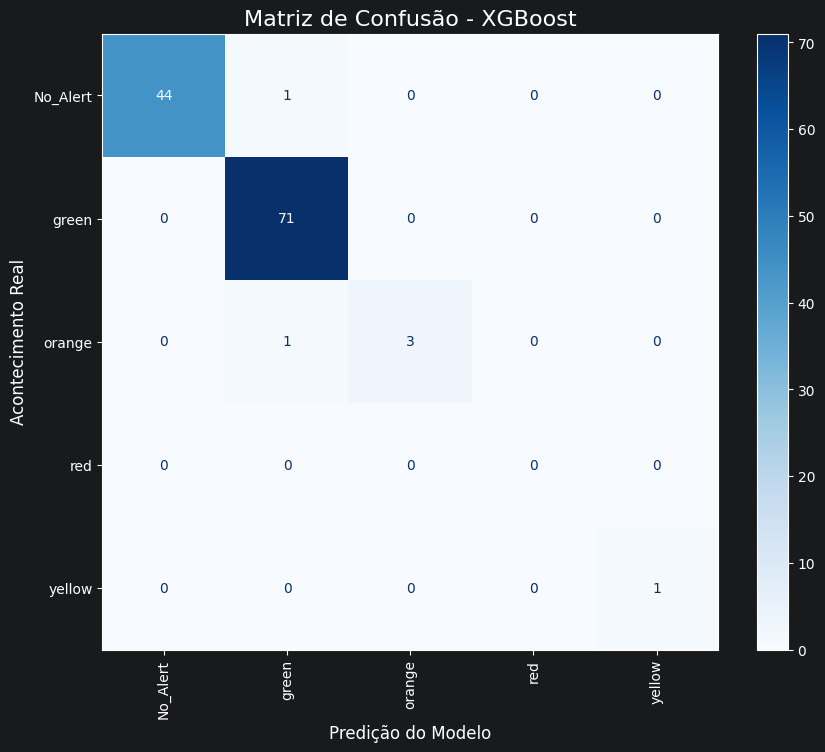

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=== Calculando todas as métricas para comparação ===\n")

results_completo = {}

# 1. Loop para calcular todas as métricas para cada modelo treinado
for name, model in trained_models.items():

    # Fazer predições no conjunto de teste
    y_pred = model.predict(X_test)

    # O CatBoost retorna um array 2D por padrão, precisamos achatar (flatten) para 1D
    if name == "CatBoost":
        y_pred = y_pred.flatten()

    # Calcular métricas usando a média 'weighted' para lidar com o desbalanceamento
    # zero_division=0 impede que o Python dê erro caso o modelo não tenha previsto nenhuma vez uma classe rara
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Guardar os resultados
    results_completo[name] = {
        'Acurácia': acc,
        'Precisão (Weighted)': prec,
        'Recall (Weighted)': rec,
        'F1-Score (Weighted)': f1
    }

# 2. Criar o DataFrame e ordenar pelo melhor F1-Score
df_resultados = pd.DataFrame(results_completo).T
df_resultados = df_resultados.sort_values(by='F1-Score (Weighted)', ascending=False)

print("🏆 Tabela de Comparação de Modelos:")
display(df_resultados)

# ---------------------------------------------------------
# 3. Extrair automaticamente o melhor modelo e gerar a Matriz
# ---------------------------------------------------------


# O índice 0 do DataFrame ordenado contém o nome do melhor modelo
melhor_modelo_nome = df_resultados.index[0]
melhor_modelo = trained_models[melhor_modelo_nome]

print(f"\nGerando Matriz de Confusão para o vencedor: {melhor_modelo_nome}")

# Refazer a predição com o vencedor
y_pred_best = melhor_modelo.predict(X_test)
if melhor_modelo_nome == "CatBoost":
    y_pred_best = y_pred_best.flatten()

# # Calcular a matriz de confusão
# cm = confusion_matrix(y_test, y_pred_best)

# 1. Pegar os números que representam as classes (ex: [0, 1, 2, 3, 4])
labels_numericos = label_encoder.transform(label_encoder.classes_)

# 2. Calcular a matriz forçando o tamanho correto (CÓDIGO NOVO)
cm = confusion_matrix(y_test, y_pred_best, labels=labels_numericos)

# Plotar visualmente
plt.figure(figsize=(10, 8))

# Se você estiver usando o mapeamento manual do passo anterior,
# substitua label_encoder.classes_ pela sua lista de classes ordenadas, ex: ['No_Alert', 'green', 'yellow', 'orange', 'red']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# cmap='Blues' deixa a matriz com um gradiente de cores onde números maiores ficam mais escuros
disp.plot(cmap='Blues', values_format='d', ax=plt.gca(), xticks_rotation='vertical')

plt.title(f'Matriz de Confusão - {melhor_modelo_nome}', fontsize=16)
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Acontecimento Real', fontsize=12)
plt.grid(False) # Remove as linhas de grade que atrapalham a leitura do heatmap
plt.show()